In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [3]:
def load_data(item_type='total', cal_func='sum'):
    """
    Loads all required data files.
    """
    print("Loading data...")
    risk_scores = pd.read_csv(f'./Data/Fama_French/risk_scores_{item_type}_{cal_func}.csv') # Load risk scores  (1a+7)
    daily_data = pd.read_csv('./Data/Fama_French/stock_daily_data.csv', parse_dates=['date'])
    factors = pd.read_csv('./Data/Fama_French/ff_factors.csv', parse_dates=['date'], index_col='date')
    return risk_scores, daily_data, factors

In [ ]:
# =============================================================================
# 2. Core Experiment Step: Portfolio Construction and Strategy Backtesting
# =============================================================================
def run_portfolio_construction(risk_scores, daily_data, splita_num=5):
    """
    Implements annual rebalancing to construct P1, P5, and LS portfolios.
    """
    print("Starting portfolio construction (annual rebalancing)...")
    
    # Determine all years that require rebalancing
    rebalance_years = sorted(risk_scores['year'].unique())
    
    all_portfolio_returns = []

    for year in rebalance_years:
        # The portfolio formation date is June 30th of year t+1, based on scores from year t.
        # The holding period is from July 1st of year t+1 to June 30th of year t+2.
        formation_date = pd.to_datetime(f'{year+1}-06-30')
        holding_period_start = pd.to_datetime(f'{year+1}-07-01')
        holding_period_end = pd.to_datetime(f'{year+2}-06-30')

        print(f"  Processing scores for year {year}, forming portfolios for {holding_period_start.year}-{holding_period_end.year}...")

        # 1. Get the risk scores for year t
        current_scores = risk_scores[risk_scores['year'] == year].copy()
        
        # 2. Group into quintiles
        # Using .loc to avoid SettingWithCopyWarning
        current_scores.loc[:, 'portfolio'] = pd.qcut(current_scores['risk_score'], splita_num, labels=False, duplicates='drop') + 1

        
        # 3. Filter daily data for the holding period
        period_data = daily_data[
            (daily_data['date'] >= holding_period_start) & 
            (daily_data['date'] <= holding_period_end)
        ]

        # 4. Merge grouping information into the daily data
        data_with_portfolio = pd.merge(period_data, current_scores[['ticker', 'portfolio']], on='ticker', how='inner')
        
        
        # 5. Calculate equal-weighted daily returns for P1 and P5 portfolios
        # Equal-weighted return = average of all stock returns within the group
        daily_returns = data_with_portfolio.groupby(['date', 'portfolio'])['return'].mean().unstack()
        
        if 1 in daily_returns.columns and splita_num in daily_returns.columns:
            low_risk_returns = daily_returns[1]
            high_risk_returns = daily_returns[splita_num]
            
            
            # 6. Construct Long-Short (LS) portfolio
            ls_returns =  low_risk_returns - high_risk_returns
            
            period_results = pd.DataFrame({
                'High Risk': high_risk_returns,
                'S&P 500 (Baseline)': period_data.groupby('date').agg(risk_score=('return', 'mean'))['risk_score'].values,
                'Low Risk': low_risk_returns,
                'LS': ls_returns
            })
            all_portfolio_returns.append(period_results)

    # Concatenate the results from all years into a single continuous time series
    final_portfolios = pd.concat(all_portfolio_returns).dropna()
    print("Portfolio construction complete.")
    return final_portfolios

SyntaxError: '(' was never closed (4154522659.py, line 30)

In [5]:
# =============================================================================
# 3. Performance Analysis and Visualization
# =============================================================================
def analyze_and_visualize(portfolios):
    """
    Calculates and prints the performance summary, and plots the cumulative return curve.
    """
    print("\n--- Table 1: Strategy Performance Summary ---")
    
    # Assume 252 trading days in a year
    trading_days = 252
    
    # Calculate performance metrics
    annual_return = portfolios.mean() * trading_days
    annual_volatility = portfolios.std() * np.sqrt(trading_days)
    sharpe_ratio = annual_return / annual_volatility # Simple Sharpe Ratio, assuming risk-free rate is 0
    
    # Calculate maximum drawdown
    cumulative_returns = (1 + portfolios).cumprod()
    peak = cumulative_returns.expanding(min_periods=1).max()
    drawdown = (cumulative_returns - peak) / peak
    max_drawdown = drawdown.min()
    
    # Format the output
    performance_summary = pd.DataFrame({
        'Annualized Return': [f"{x:.2%}" for x in annual_return],
        'Annualized Volatility': [f"{x:.2%}" for x in annual_volatility],
        'Sharpe Ratio': [f"{x:.2f}" for x in sharpe_ratio],
        'Max Drawdown': [f"{x:.2%}" for x in max_drawdown]
    }, index=portfolios.columns)
    
    print(performance_summary)
    
    # --- Visualization ---
    print("\nGenerating cumulative return curve plot (figure_1_cumulative_returns.png)...")
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 7))
    
    for col in cumulative_returns.columns:
        ax.plot(cumulative_returns.index, cumulative_returns[col], label=col)

    ax.set_title('Portfolio Cumulative Returns', fontsize=16)
    ax.set_ylabel('Cumulative Return', fontsize=12)
    ax.set_xlabel('Date', fontsize=12)
    ax.legend(title='Portfolio', fontsize=10)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('figure_1_cumulative_returns.png', dpi=300)
    print("Plot saved.")

In [6]:
# =============================================================================
# 4. Fama-French Three-Factor Regression Analysis
# =============================================================================
def run_regression_analysis(ls_portfolio, factors):
    """
    Performs a three-factor regression on the LS long-short portfolio.
    """
    print("\n--- Table 2: LS Strategy Three-Factor Regression Results ---")
    
    # Merge data
    data_for_regression = pd.merge(ls_portfolio, factors, left_index=True, right_index=True, how='inner')
    
    # Dependent variable Y: LS portfolio return (Long-short is self-financing, no need to subtract RF)
    Y = data_for_regression['LS']
    
    # Independent variables X: Fama-French three factors
    X = data_for_regression[['MKT-RF', 'SMB', 'HML']]
    X = sm.add_constant(X) # Add a constant (intercept)
    
    # Run OLS regression
    model = sm.OLS(Y, X).fit()
    
    # Extract and format results
    # Annualize the daily alpha
    annualized_alpha = model.params['const'] * 252
    
    results_summary = pd.DataFrame({
        'Coefficient': model.params,
        't-statistic': model.tvalues
    })
    
    # Adjust the display for Alpha
    results_summary.loc['const', 'Coefficient'] = annualized_alpha
    results_summary = results_summary.rename(index={'const': 'Alpha (Annualized)'})
    
    print(results_summary.round(4))
    print(f"\nAdjusted R-squared: {model.rsquared_adj:.4f}")

    # Interpretation of Results
    alpha_t_stat = model.tvalues['const']
    if abs(alpha_t_stat) > 1.96:
        print(f"\nConclusion: Alpha is statistically significant at the 5% level (t={alpha_t_stat:.2f}).")
        print("This provides strong evidence that your risk score offers independent information not captured by traditional factors.")
    else:
        print(f"\nConclusion: Alpha is not statistically significant at the 5% level (t={alpha_t_stat:.2f}).")
        print("The strategy's returns can be well explained by the Fama-French three factors.")


Loading data...
Starting portfolio construction (annual rebalancing)...
  Processing scores for year 2020, forming portfolios for 2021-2022...
    Low Risk Portfolio Tickers: ['ABBV' 'ADP' 'AKAM' 'AMD' 'BLDR' 'CAT' 'CCI' 'CME' 'CMG' 'CTVA' 'FDS'
 'GPC' 'KMI' 'MCO' 'MLM' 'MRNA' 'MU' 'NEE' 'O' 'PKG' 'PM' 'VRTX' 'WST']
    High Risk Portfolio Tickers: ['APTV' 'CHTR' 'CL' 'CMCSA' 'CNP' 'EL' 'EMN' 'EXPD' 'GD' 'GNRC' 'HII'
 'HLT' 'KMB' 'LII' 'LMT' 'LNT' 'MA' 'PRU' 'SLB']
  Processing scores for year 2021, forming portfolios for 2022-2023...
    Low Risk Portfolio Tickers: ['AMD' 'ATO' 'BFB' 'CCI' 'CPB' 'CSGP' 'DHI' 'DUK' 'FDS' 'GLW' 'MO' 'MPWR'
 'NOW' 'NUE' 'PODD' 'SBAC' 'SNA' 'SRE' 'STE' 'TDY' 'TROW' 'UBER' 'WST'
 'XEL']
    High Risk Portfolio Tickers: ['ALL' 'APTV' 'DG' 'EL' 'EMN' 'EW' 'EXPE' 'GD' 'GL' 'KMB' 'LLY' 'NKE'
 'PKG' 'RSG' 'RTX' 'TER' 'UNH']
  Processing scores for year 2022, forming portfolios for 2023-2024...
    Low Risk Portfolio Tickers: ['ADP' 'AMT' 'CHRW' 'CHTR' 'CPRT' 'E

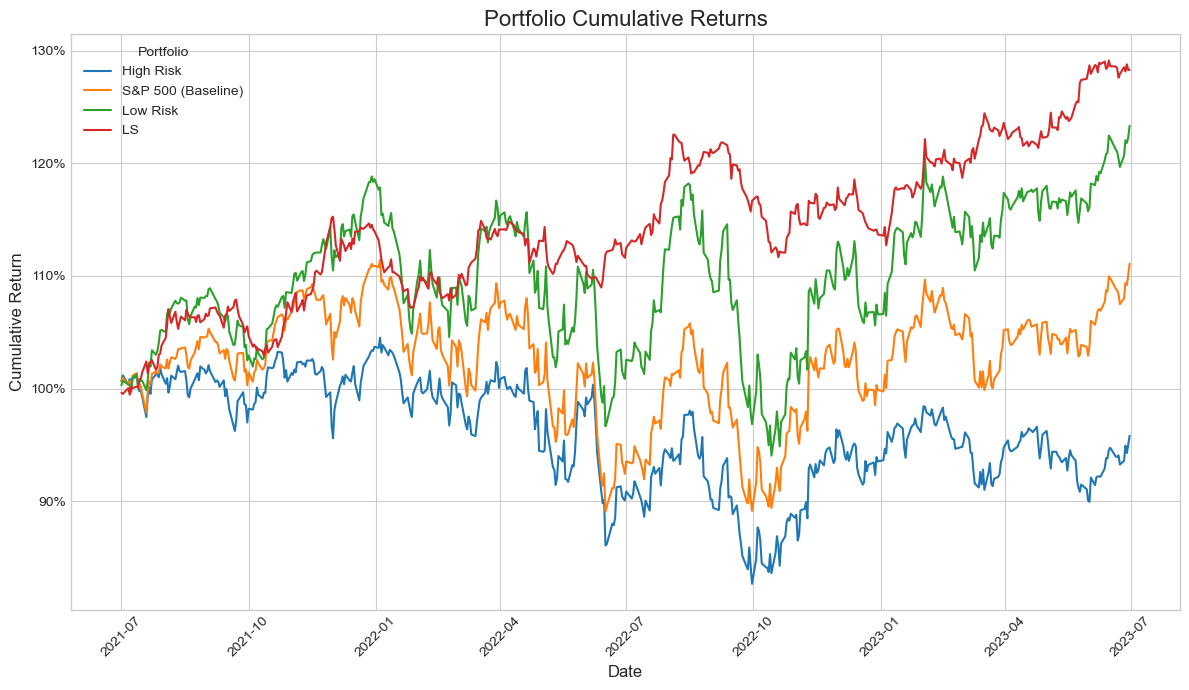

In [29]:
# 1. Load data
risk_scores, daily_data, factors = load_data('item_7', 'sum')

# 2. Construct portfolios
portfolios = run_portfolio_construction(risk_scores, daily_data, splita_num=20)
        
# 3. Analyze performance and visualize
analyze_and_visualize(portfolios)
        
# 4. Run regression analysis
run_regression_analysis(portfolios[['LS']], factors)